# LOO-CV with a Gaussian process: the GJ 357 system

This notebook performs LOO-CV for RV observations of the GJ 357 system (Luque et al. 2019), calculating the per-measurement difference in expected log predictive density between a four-planet and a three-planet model.

Similarly to the GJ 4276 notebook, it uses existing posterior samples rather than redoing the RV fit.

### Background: why a Gaussian process changes the calculation

For an uncorrelated noise model the likelihood factorises over the data, so the pointwise quantity
that LOO-CV needs is just the likelihood of each measurement on its own. A GP couples every
measurement to every other, and that factorisation is lost. The quantity required is instead the
*conditional* predictive density of each measurement given all the others,

$$\log p(d_i \mid d_{-i}, \theta) = -\tfrac{1}{2}\left[\log 2\pi\hat\sigma_i^2 + \frac{(r_i-\mu_i)^2}{\hat\sigma_i^2}\right],
\qquad \hat\sigma_i^2 = \frac{1}{[K^{-1}]_{ii}}, \qquad \mu_i = r_i - \frac{[K^{-1}r]_i}{[K^{-1}]_{ii}},$$

where $r = d - m(\theta)$ are the residuals to the deterministic (Keplerian plus offset) model and
$K$ is the full covariance matrix. These identities follow from the standard Gaussian conditioning
formulae, and give the leave-one-out conditional for every $i$ from a single inverse of $K$ rather
than from $N$ separate ones.

Once this array has been built, PSIS applies unchanged, with importance ratios
$r_i^s = 1/p(d_i \mid d_{-i}, \theta^s)$.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import arviz as az

AUX_DIR  = 'auxiliary_data'   # posterior samples, downloaded separately (see README)

print('numpy', np.__version__, '| arviz', az.__version__)

numpy 2.4.6 | arviz 0.23.4


## 1. Data

141 radial velocities of GJ 357 from Luque et al. (2019), combining Keck/HIRES, VLT/UVES, HARPS,
Magellan/PFS (split into PFSpre and PFSpost either side of the February 2018 slit change) and
CARMENES.

The measurements have to be held in exactly the order `juliet` used internally when it evaluated
the likelihood, because the posterior samples we are about to load were produced in that order.
`juliet` concatenates the instruments in the order they first appear in the file, keeping each
instrument's own rows in file order. We build that ordering here and carry the times along with it,
so that the elpd values and the epochs they belong to cannot become separated.

In [2]:
rv_file = os.path.join(AUX_DIR, 'gj357_rvs.dat')

t_file    = np.loadtxt(rv_file, usecols=0)
y_file    = np.loadtxt(rv_file, usecols=1)
e_file    = np.loadtxt(rv_file, usecols=2)
inst_file = np.loadtxt(rv_file, usecols=3, dtype=str)

# Instruments in order of first appearance, which is the order juliet concatenates them in
INSTRUMENTS = list(dict.fromkeys(inst_file.tolist()))

# Reorder into juliet's instrument-grouped ordering
order_to_juliet = np.concatenate([np.where(inst_file == name)[0] for name in INSTRUMENTS])
t_all    = t_file[order_to_juliet]
y_all    = y_file[order_to_juliet]
e_all    = e_file[order_to_juliet]
inst_all = inst_file[order_to_juliet]

N  = len(t_all)
DT = np.abs(t_all[:, None] - t_all[None, :])   # |t_i - t_j|, used by the kernel

print(f'{N} measurements, {t_file.max() - t_file.min():.0f} d baseline '
      f'({(t_file.max() - t_file.min()) / 365.25:.1f} yr)')
for name in INSTRUMENTS:
    print(f'  {name:9s} {int((inst_file == name).sum()):3d}')
print(f'\njuliet ordering: {INSTRUMENTS}')

141 measurements, 7788 d baseline (21.3 yr)
  HIRES      32
  UVES       30
  HARPS      53
  PFSpre      7
  CARMENES   10
  PFSpost     9

juliet ordering: ['HIRES', 'UVES', 'HARPS', 'PFSpre', 'CARMENES', 'PFSpost']


## 2. Posterior samples

Here we load the equally weighted posterior samples from the two published `juliet` runs, one file per model.
Each file holds every free parameter, the log evidence, and `loglike`, the joint log-likelihood
`juliet` recorded for each sample, which section 4 uses as an independent check on our own model
reconstruction.

In [3]:
def load_posterior(n_planets):
    z = np.load(os.path.join(AUX_DIR, f'GJ357_{n_planets}P_GP_posterior.npz'))
    return {k: z[k] for k in z.files}

post = {n: load_posterior(n) for n in (3, 4)}

for n in (3, 4):
    p = post[n]
    print(f'{n}-planet model: {len(p["loglike"]):,} samples, '
          f'ln Z = {float(p["lnZ"]):.2f} +/- {float(p["lnZerr"]):.2f}')

print(f'\nDelta ln Z (4 planets - 3 planets) = '
      f'{float(post[4]["lnZ"]) - float(post[3]["lnZ"]):.2f}')

3-planet model: 126,754 samples, ln Z = -373.35 +/- 0.63
4-planet model: 138,656 samples, ln Z = -369.94 +/- 0.67

Delta ln Z (4 planets - 3 planets) = 3.41


## 3. Rebuilding the model

To evaluate the conditional predictive densities we need the residuals and the covariance matrix
for every posterior sample, so both have to be reconstructed here. Because all eccentricities are
fixed to zero, the Keplerians are plain sinusoids and the deterministic model can be written out
explicitly. We therefore reconstruct the model here, so that no installation of `juliet` is needed. We then check that our reconstruction matches the computed likelihoods.

In [4]:
def deterministic_model(ps, idx, n_planets):
    # Circular Keplerians plus per-instrument velocity offsets, for a batch of samples
    m = np.zeros((len(idx), N))
    for p in range(1, n_planets + 1):
        m += -ps[f'K_p{p}'][idx, None] * np.sin(
            2 * np.pi * (t_all[None, :] - ps[f't0_p{p}'][idx, None]) / ps[f'P_p{p}'][idx, None])
    for name in INSTRUMENTS:
        m[:, inst_all == name] += ps[f'mu_{name}'][idx, None]
    return m


def covariance(ps, idx):
    # k(dt) = GP_sigma_rv * exp(-GP_timescale_rv * dt), i.e. a celerite RealTerm,
    # plus the quoted errors and the per-instrument jitter on the diagonal
    Kg = ps['GP_sigma_rv'][idx, None, None] * np.exp(
        -ps['GP_timescale_rv'][idx, None, None] * DT[None])
    sw2 = np.zeros((len(idx), N))
    for name in INSTRUMENTS:
        sw2[:, inst_all == name] = ps[f'sigma_w_{name}'][idx, None] ** 2
    eye = np.eye(N)[None]
    return Kg + (e_all[None, :] ** 2 + sw2)[:, :, None] * eye + 1e-10 * eye


def joint_loglike(ps, idx, n_planets):
    # -0.5 * [ r^T K^-1 r + log|K| + N log 2pi ], via the Cholesky factor
    r = y_all[None, :] - deterministic_model(ps, idx, n_planets)
    K = covariance(ps, idx)
    L = np.linalg.cholesky(K)
    a = np.linalg.solve(np.swapaxes(L, -1, -2), np.linalg.solve(L, r[..., None]))[..., 0]
    return -0.5 * (np.einsum('si,si->s', r, a)
                   + 2 * np.log(np.einsum('sii->si', L)).sum(axis=1)
                   + N * np.log(2 * np.pi))


CHECK = np.arange(2000)          # first 2000 samples
for n in (3, 4):
    ours = joint_loglike(post[n], CHECK, n)
    diff = np.abs(ours - post[n]['loglike'][CHECK]).max()
    print(f'{n}P self-check: max |our log-likelihood - juliet\'s| = {diff:.2e}')
    assert diff < 1e-6, 'model reconstruction does not match juliet'

print('\nBoth models reproduce juliet\'s stored log-likelihoods to machine precision:\n'
      'the deterministic model, the covariance and the data ordering are all correct.')

3P self-check: max |our log-likelihood - juliet's| = 6.49e-09


4P self-check: max |our log-likelihood - juliet's| = 7.01e-09

Both models reproduce juliet's stored log-likelihoods to machine precision:
the deterministic model, the covariance and the data ordering are all correct.


## 4. Leave-one-out cross-validation with a Gaussian process

The conditional predictive density is now evaluated for every measurement and every posterior
sample. The three quantities in the expression at the top of the notebook all come from a single
inverse of $K$ per sample, so the whole leave-one-out array costs one $N \times N$ inversion per
sample rather than $N$ of them. The samples are batched so that the inversions are done in bulk. This step takes around 2 minutes per model.

In [5]:
BATCH = 400

def pointwise_conditional(ps, idx, n_planets):
    # log p(d_i | d_-i, theta) for every measurement, for each sample in the batch
    r = y_all[None, :] - deterministic_model(ps, idx, n_planets)
    Kinv = np.linalg.inv(covariance(ps, idx))
    diag  = np.einsum('sii->si', Kinv)          # [K^-1]_ii
    alpha = np.einsum('sij,sj->si', Kinv, r)    # [K^-1 r]_i
    s2 = 1.0 / diag                             # conditional variance
    # r_i - mu_i = alpha_i / diag_i, so the residual term is (alpha/diag)^2 / s2
    return -0.5 * (np.log(2 * np.pi * s2) + (alpha / diag) ** 2 / s2)


loglike = {}
for n in (3, 4):
    ps = post[n]
    ns = len(ps['loglike'])
    out = np.empty((ns, N))
    for k in range(0, ns, BATCH):
        sl = slice(k, min(k + BATCH, ns))
        out[sl] = pointwise_conditional(ps, np.arange(sl.start, sl.stop), n)
    loglike[n] = out
    print(f'{n}P: conditional predictive densities for {ns:,} samples x {N} measurements')

3P: conditional predictive densities for 126,754 samples x 141 measurements


4P: conditional predictive densities for 138,656 samples x 141 measurements


## 5. Pareto-smoothed importance sampling

`arviz` does the PSIS step, exactly as it would for an uncorrelated model. A shape parameter $k > 0.7$ for any measurement would mean the
importance sampling approximation cannot be trusted there and that the model must be refitted with
that measurement withheld. This does not occur here, so no exact refits are needed.

Note that `arviz` behaves slightly differently depending on the version used. Expect slightly different results depending on whether version 0 or version 1 is installed. The code below has been built to support both versions.

In [6]:
# arviz changed its interface at version 1.0: xarray's DataTree replaced InferenceData, and the
# loo result attributes were renamed (elpd_loo -> elpd, loo_i -> elpd_i).
_ARVIZ_LEGACY = hasattr(az, 'convert_to_inference_data')

def psis_loo(ll):
    ll3 = np.expand_dims(ll, 0)                       # (chain, draw, observation)
    if _ARVIZ_LEGACY:                                 # arviz < 1.0
        idata = az.convert_to_inference_data(ll3, group='log_likelihood')
        idata.add_groups(posterior={'placeholder': np.ones_like(ll3)})
        return az.loo(idata, var_name='x', pointwise=True, reff=1.0)
    idata = az.from_dict({'log_likelihood': {'y': ll3},
                          'posterior': {'placeholder': np.ones(ll3.shape[:2])}})
    return az.loo(idata, var_name='y', pointwise=True, reff=1.0)

def elpd_total(r):
    return float(r.elpd if hasattr(r, 'elpd') else r.elpd_loo)

def elpd_pointwise(r):
    return np.asarray(r.elpd_i if hasattr(r, 'elpd_i') else r.loo_i)

print('arviz', az.__version__, '(legacy API)' if _ARVIZ_LEGACY else '(>= 1.0 API)')
loo = {n: psis_loo(loglike[n]) for n in (3, 4)}
for n in (3, 4):
    k = np.asarray(loo[n].pareto_k)
    print(f'{n}P: elpd_LOO = {elpd_total(loo[n]):8.2f}  SE = {float(loo[n].se):5.2f}  '
          f'max Pareto k = {k.max():.2f}  ({int((k > 0.7).sum())} above 0.7)')

arviz 0.23.4 (legacy API)


3P: elpd_LOO =  -339.39  SE =  8.31  max Pareto k = 0.54  (0 above 0.7)
4P: elpd_LOO =  -338.76  SE =  8.76  max Pareto k = 0.63  (0 above 0.7)


## 6. Results and plotting

Now we can compute $\Delta\mathrm{elpd}_\mathrm{LOO}$, the difference between the four-planet and three-planet
models, summed over measurements. We can also check the standard error.

The per-point values are then plotted over the full baseline of the observations.

Delta elpd_LOO (4 planets - 3 planets) = 0.63
Standard error                         = 3.17


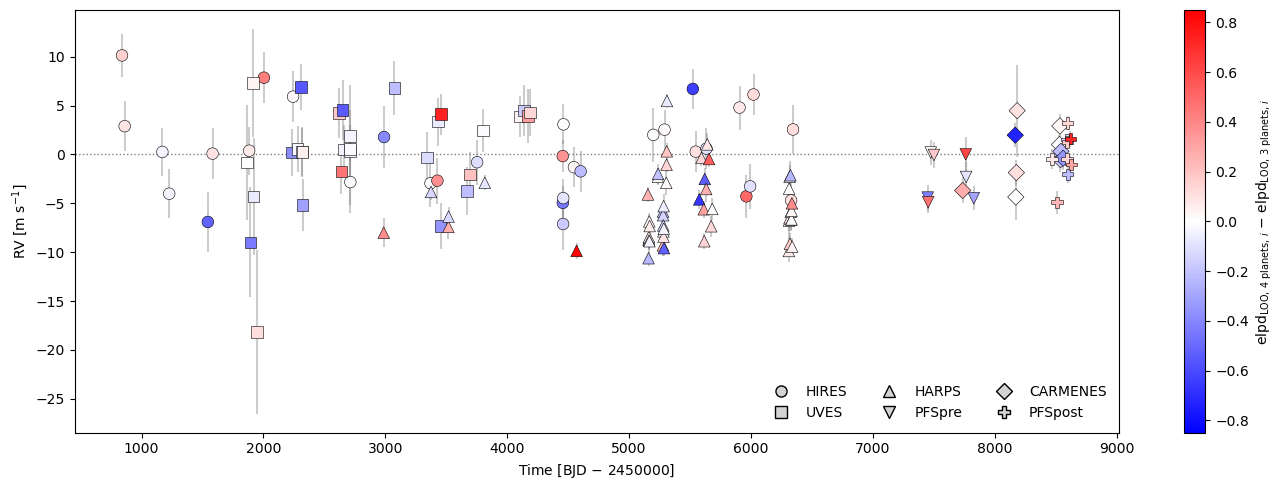

In [7]:
loo_i = {n: elpd_pointwise(loo[n]) for n in (3, 4)}
d_i   = loo_i[4] - loo_i[3]
d_tot = d_i.sum()
se    = np.sqrt(N * np.var(d_i))

print(f'Delta elpd_LOO (4 planets - 3 planets) = {d_tot:.2f}')
print(f'Standard error                         = {se:.2f}')

MARKERS = {'HIRES': 'o', 'UVES': 's', 'HARPS': '^', 'PFSpre': 'v', 'CARMENES': 'D', 'PFSpost': 'P'}
CLIM = 0.85

fig, ax = plt.subplots(figsize=(14, 5))
ax.axhline(0.0, ls=':', lw=1, color='grey', zorder=0)
ax.errorbar(t_all - 2450000, y_all, yerr=e_all, fmt='none', ecolor='grey', alpha=0.4, zorder=1)

for name, marker in MARKERS.items():
    m = inst_all == name
    sc = ax.scatter(t_all[m] - 2450000, y_all[m], c=d_i[m], cmap='bwr', marker=marker,
                    s=70, edgecolor='k', linewidth=0.4, vmin=-CLIM, vmax=CLIM,
                    label=name, zorder=2)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label(r'elpd$_{\rm LOO,\,4\ planets,\,\it i}$ $-$ elpd$_{\rm LOO,\,3\ planets,\,\it i}$')
ax.set_xlabel('Time [BJD $-$ 2450000]')
ax.set_ylabel('RV [m s$^{-1}$]')
# Neutral legend markers, so the shapes are not confused with the colour scale
handles = [Line2D([], [], marker=mk, color='none', markerfacecolor='lightgrey',
                  markeredgecolor='k', markersize=8, label=nm)
           for nm, mk in MARKERS.items()]
ax.legend(handles=handles, loc='lower right', ncol=3, frameon=False)
fig.tight_layout()
plt.show()